## Fetching Data

First step would be to fetch the data from the three datasets and store the datasets to three variables

In [3]:
import os
import pandas as pd
from supabase import create_client
from dotenv import load_dotenv

load_dotenv()
supabase = create_client(os.environ["SUPABASE_URL"], os.environ["SUPABASE_KEY"])

def fetch_table(name: str, batch_size: int = 1000, limit: int | None = None) -> pd.DataFrame:
    rows, start = [], 0
    while True:
        end = start + batch_size - 1
        resp = supabase.table(name).select("*").range(start, end).execute()
        batch = resp.data or []
        rows.extend(batch)
        if len(batch) < batch_size or (limit and len(rows) >= limit):
            break
        start += batch_size
    if limit:
        rows = rows[:limit]
    return pd.DataFrame(rows)

try:
    crimes_df = fetch_table("chicago_crimes")
    print(f"Fetched {len(crimes_df)} rows from chicago_crimes")
except Exception as e:
    print(f"Failed to load chicago_crimes: {e}")

try:
    accident_df = fetch_table("chicago_accident_cleaned")
    print(f"Fetched {len(accident_df)} rows from chicago_accident_cleaned")
except Exception as e:
    print(f"Failed to load chicago_accident_cleaned: {e}")

try:
    moon_df = fetch_table("cleaned_moon_data")
    print(f"Fetched {len(moon_df)} rows from cleaned_moon_data")
except Exception as e:
    print(f"Failed to load cleaned_moon_data: {e}")


Fetched 251337 rows from chicago_crimes
Fetched 110720 rows from chicago_accident_cleaned
Fetched 1826 rows from cleaned_moon_data


In [5]:
print("Crimes Dataset Columns:", crimes_df.columns)
print("\n\nMoon Dataset Columns:", moon_df.columns)
print("\n\nTraffic Dataset Columns:", accident_df.columns)

Crimes Dataset Columns: Index(['id', 'created_at', 'date_only', 'primary_type', 'location_description',
       'arrest', 'domestic', 'crime_count'],
      dtype='object')


Moon Dataset Columns: Index(['date', 'avg_phase', 'avg_age', 'avg_distance', 'avg_diameter',
       'moon_category', 'created_at'],
      dtype='object')


Traffic Dataset Columns: Index(['id', 'crash_date', 'weather_condition', 'lighting_condition',
       'trafficway_type', 'roadway_surface_cond', 'injuries_total',
       'incidents_count'],
      dtype='object')


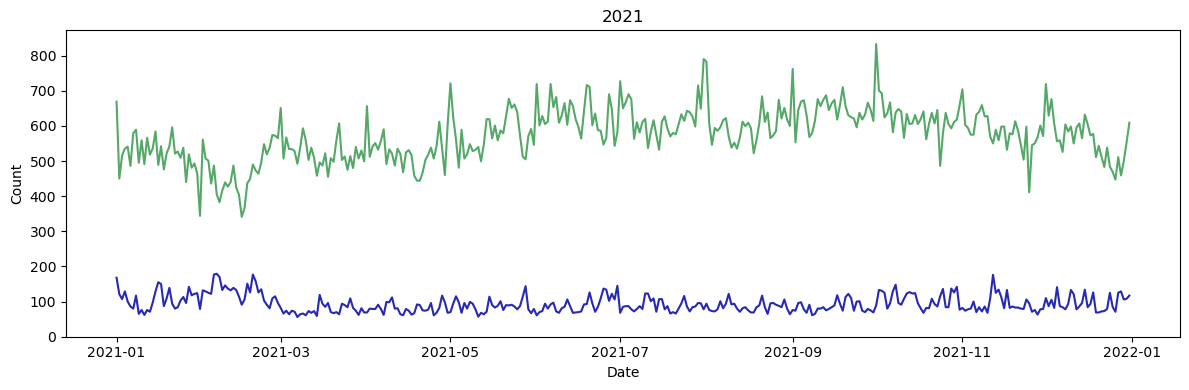

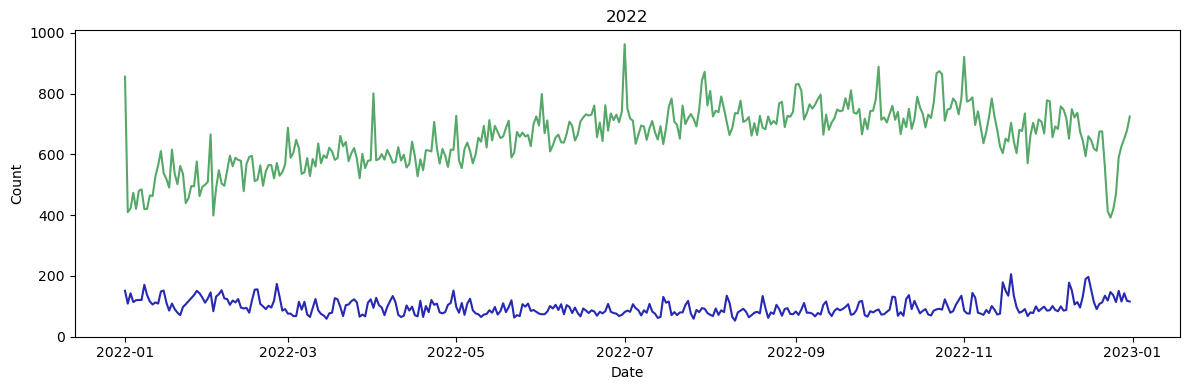

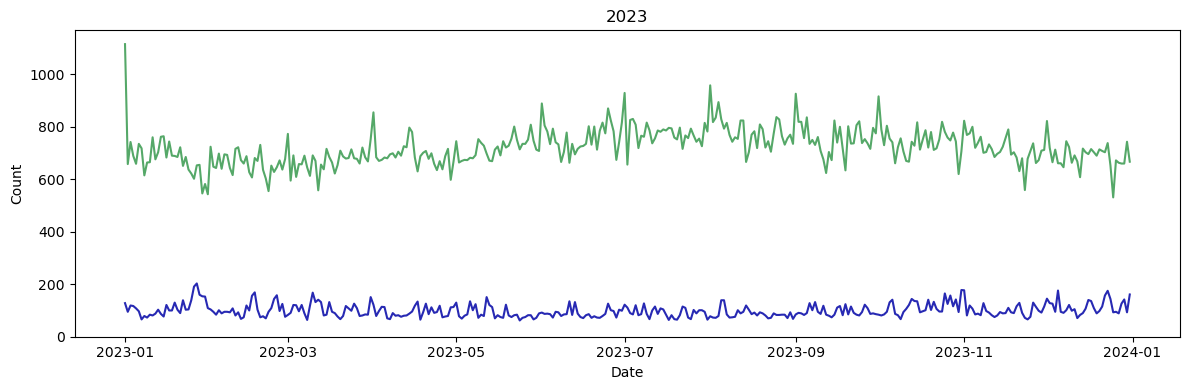

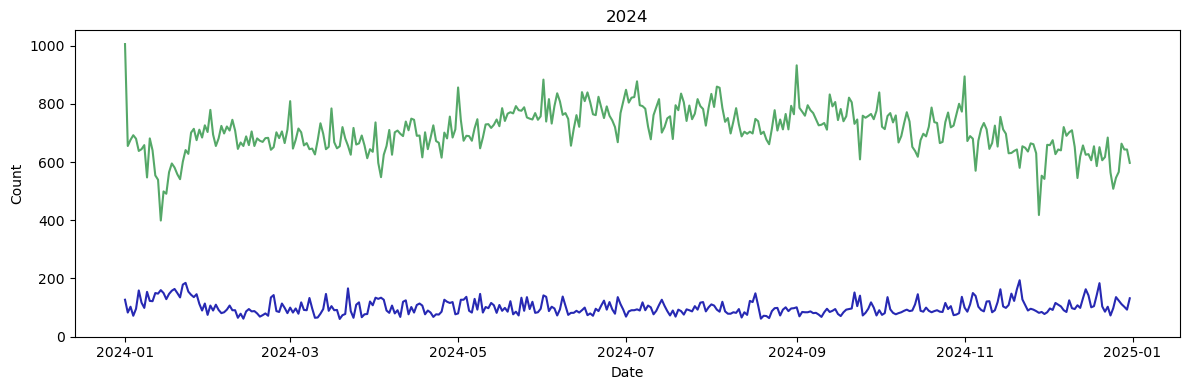

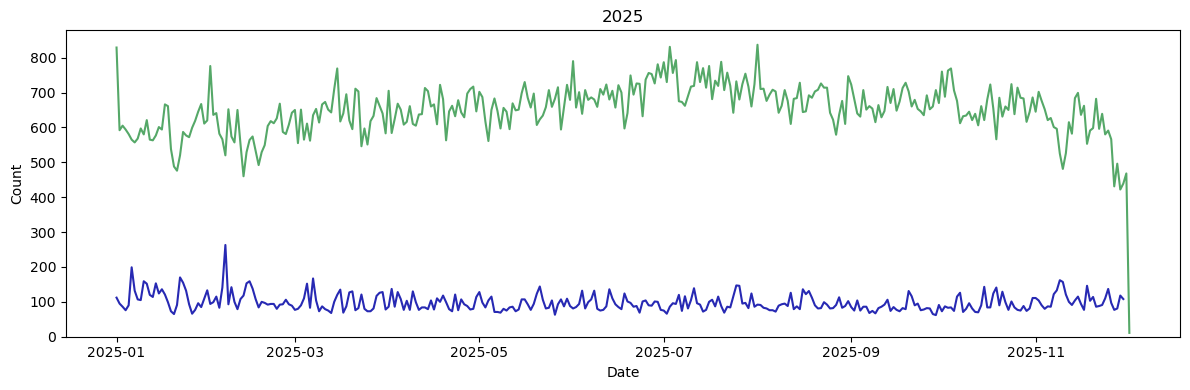

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Daily trend
years = [2021, 2022, 2023, 2024, 2025]

for y in years:
    crimes_by_day = (
        crimes_df.assign(date_only=pd.to_datetime(crimes_df["date_only"]))
        .loc[lambda d: d["date_only"].dt.year == y]
        .groupby("date_only")["crime_count"].sum()
        .reset_index()
        .sort_values("date_only")
    )

    accidents_by_day = (
        accident_df.assign(crash_date=pd.to_datetime(accident_df["crash_date"]))
        .loc[lambda d: d["crash_date"].dt.year == y]
        .groupby("crash_date")["incidents_count"].sum()
        .reset_index()
        .sort_values("crash_date")
    )

    plt.figure(figsize=(12, 4))
    sns.lineplot(data=accidents_by_day, x="crash_date", y="incidents_count", color="#2729B3")
    sns.lineplot(data=crimes_by_day, x="date_only", y="crime_count", color="#55A868")
    plt.title(y)
    plt.xlabel("Date")
    plt.ylabel("Count")
    plt.ylim(bottom=0)
    plt.tight_layout()
    plt.show()

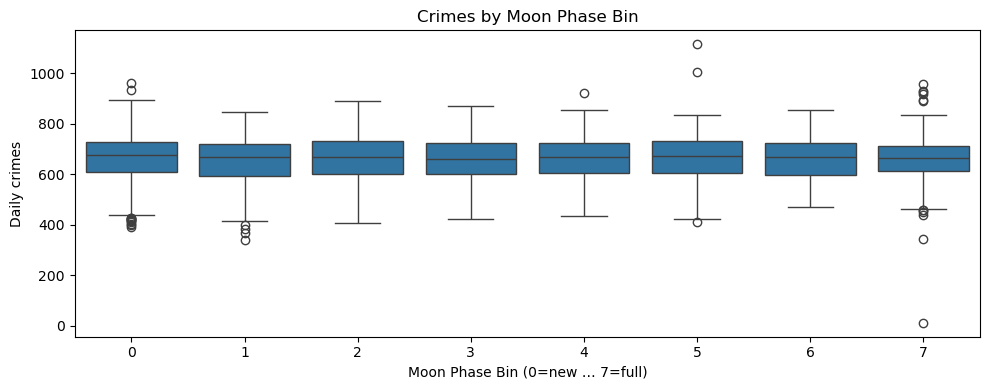

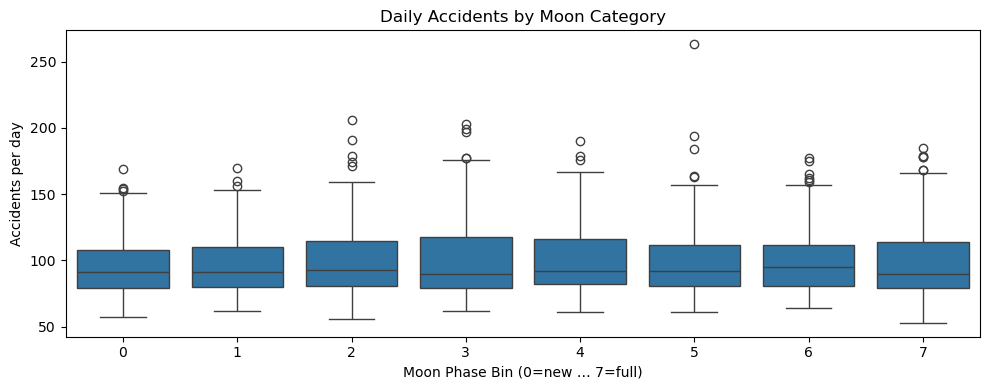

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

crimes_daily = crimes_df.groupby("date_only")["crime_count"].sum().reset_index().rename(columns={"date_only":"date"})
acc_daily = accident_df.groupby("crash_date")["incidents_count"].sum().reset_index().rename(columns={"crash_date":"date"})

crimes_daily["date"] = pd.to_datetime(crimes_daily["date"])
acc_daily["date"] = pd.to_datetime(acc_daily["date"])
moon_df["date"] = pd.to_datetime(moon_df["date"])

merged = (
    moon_df
    .merge(crimes_daily, on="date", how="left")
    .merge(acc_daily, on="date", how="left")
)

# Bin phase into 8 buckets (0–1 range)
merged["phase_bin"] = pd.cut(merged["avg_phase"], bins=8, labels=False)

# Boxplot by phase_bin
plt.figure(figsize=(10,4))
sns.boxplot(data=merged, x="phase_bin", y="crime_count")
plt.title("Crimes by Moon Phase Bin")
plt.xlabel("Moon Phase Bin (0=new … 7=full)")
plt.ylabel("Daily crimes")
plt.tight_layout()
plt.show()

# Boxplot by phase_bin
plt.figure(figsize=(10, 4))
sns.boxplot(data=merged, x="phase_bin", y="incidents_count")
plt.title("Daily Accidents by Moon Category")
plt.xlabel("Moon phase category")
plt.xlabel("Moon Phase Bin (0=new … 7=full)")
plt.ylabel("Accidents per day")
plt.tight_layout()
plt.show()


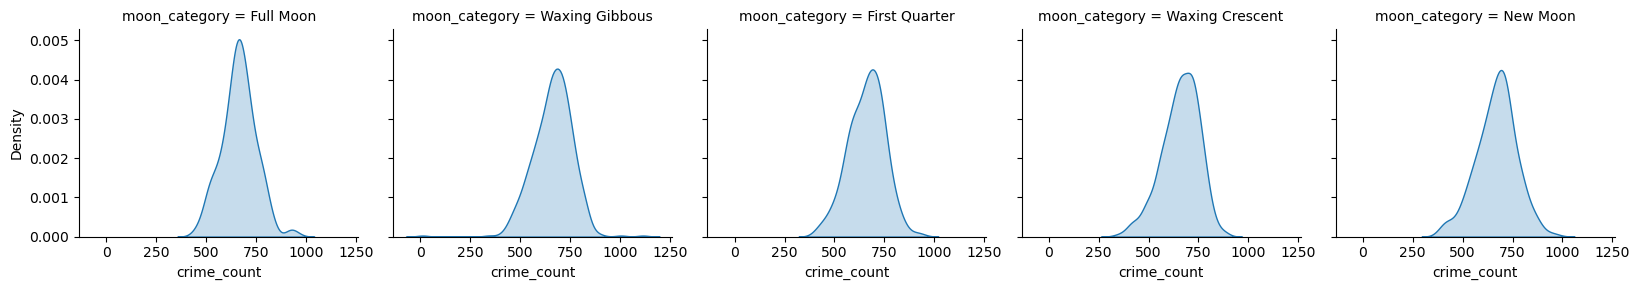

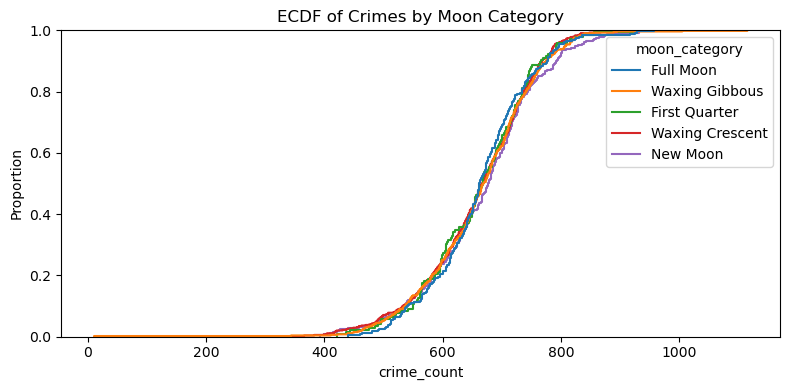

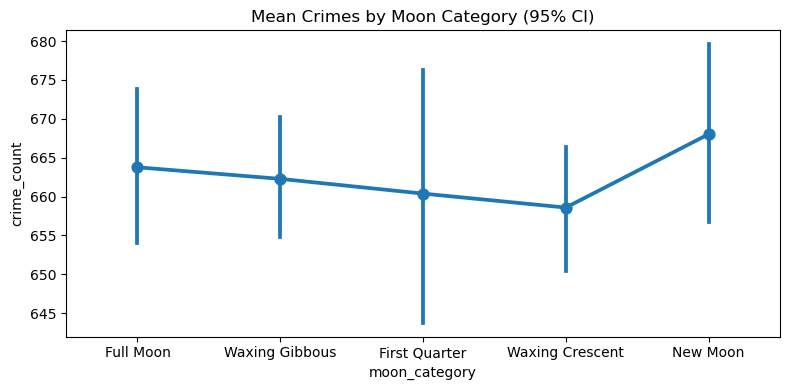

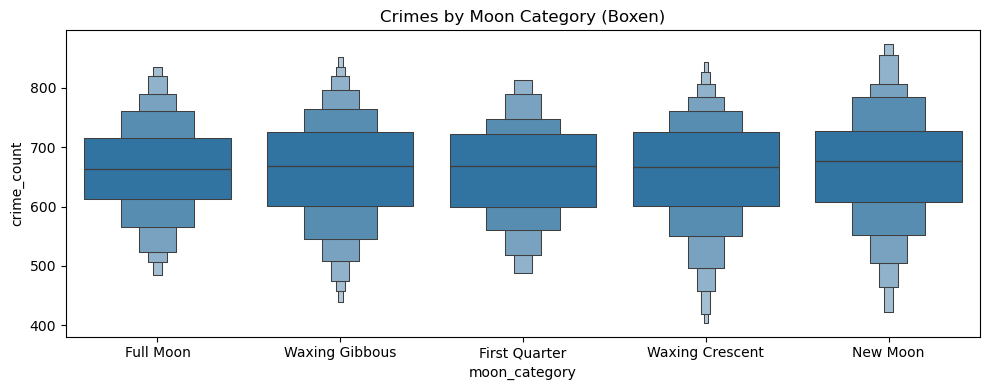

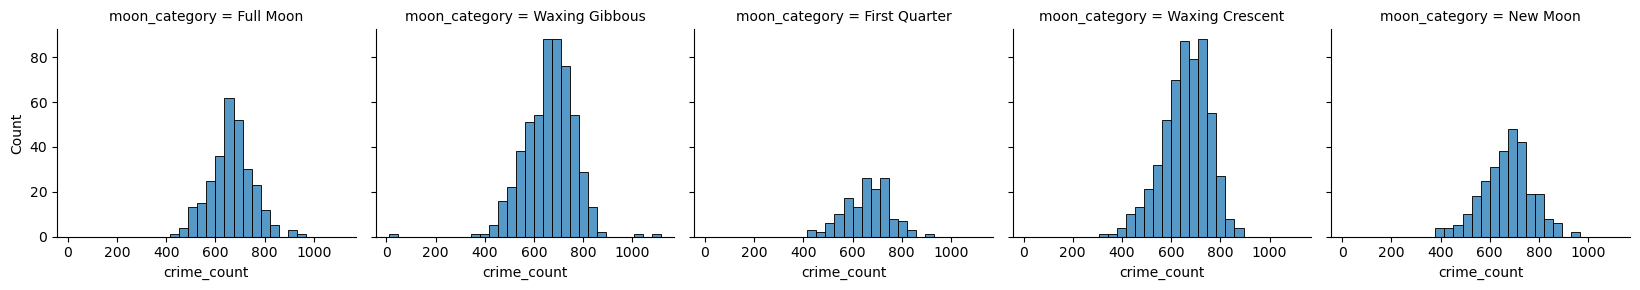

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1) KDE facets
sns.displot(data=merged, x="crime_count", col="moon_category",
            kind="kde", fill=True, common_norm=False, height=3, aspect=1.1)

# 2) ECDF
plt.figure(figsize=(8, 4))
sns.ecdfplot(data=merged, x="crime_count", hue="moon_category")
plt.title("ECDF of Crimes by Moon Category")
plt.tight_layout()

# 3) Point plot (mean + 95% CI)
plt.figure(figsize=(8, 4))
sns.pointplot(data=merged, x="moon_category", y="crime_count",
              estimator=np.mean, errorbar=("ci", 95))
plt.title("Mean Crimes by Moon Category (95% CI)")
plt.tight_layout()

# 4) Boxen plot (more quantiles)
plt.figure(figsize=(10, 4))
sns.boxenplot(data=merged, x="moon_category", y="crime_count", showfliers=False)
plt.title("Crimes by Moon Category (Boxen)")
plt.tight_layout()

# 5) Histogram facets
sns.displot(data=merged, x="crime_count", col="moon_category",
            bins=30, common_bins=True, height=3, aspect=1.1)

plt.show()


In [62]:
category_counts = moon_df['moon_category'].value_counts(dropna=False)
print(category_counts)
# or as a DataFrame
category_counts_df = (
    moon_df['moon_category']
    .value_counts(dropna=False)
    .rename_axis('category')
    .reset_index(name='count')
)

moon_category
Waxing Crescent    560
Waxing Gibbous     549
Full Moon          286
New Moon           285
First Quarter      146
Name: count, dtype: int64


In [76]:
import json, pandas as pd

with open("mooninfo_2021.json", "r") as f:
    moon_raw = json.load(f)

df = pd.json_normalize(moon_raw)


In [94]:
import json, pandas as pd

with open("mooninfo_2021.json") as f:
    df = pd.json_normalize(json.load(f))

df["time"] = pd.to_datetime(df["time"], format="%d %b %Y %H:%M UT")
df = df.sort_values("time")
df["illum_frac"] = df["phase"] / 100.0
df["date"] = df["time"].dt.date

# daily average illumination
daily = (
    df.groupby("date", as_index=False)["illum_frac"]
      .mean()
      .sort_values("date")
      .rename(columns={"illum_frac": "illum_avg"})
)

# daily waxing flag from day-to-day change
daily["is_waxing"] = daily["illum_avg"].diff().fillna(0) >= 0

def phase_bucket(val, waxing):
    if val < 0.05:
        return "New Moon"
    if val < 0.45:
        return "Waxing Crescent" if waxing else "Waning Crescent"
    if val < 0.55:
        return "First Quarter" if waxing else "Last Quarter"
    if val < 0.95:
        return "Waxing Gibbous" if waxing else "Waning Gibbous"
    return "Full Moon"

daily["phase_bucket"] = [
    phase_bucket(v, w) for v, w in zip(daily["illum_avg"], daily["is_waxing"])
]

print(daily.head())            # per-day avg + phase
print(daily["phase_bucket"].value_counts())  # counts by phase across days



         date  illum_avg  is_waxing    phase_bucket
0  2021-01-01   0.940833       True  Waxing Gibbous
1  2021-01-02   0.881383      False  Waning Gibbous
2  2021-01-03   0.803304      False  Waning Gibbous
3  2021-01-04   0.709621      False  Waning Gibbous
4  2021-01-05   0.604296      False  Waning Gibbous
phase_bucket
Waning Crescent    63
Waning Gibbous     61
Waxing Gibbous     58
Waxing Crescent    58
Full Moon          50
New Moon           50
Last Quarter       13
First Quarter      12
Name: count, dtype: int64
